In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df_table = pd.read_csv("MBH_table_final.csv")

In [3]:
df_table.head()

,Galaxy,M_BH,M_BH_lower,M_BH_upper,sigma,Morph,Method,Source,Paper reference,MASSIVE?,BCG?,Limits source (for filled rows only)
0,A1836,3900000000,3300000000,4300000000,288.0,E,gas,MM13,NaN,NaN,NaN,NaN
1,A3565,1400000000,1200000000,1700000000,322.0,E,gas,MM13,NaN,NaN,NaN,NaN
2,CIRC,1700000,1400000,2100000,158.0,S,maser,MM13,NaN,NaN,NaN,NaN
3,IC1459,2800000000,1600000000,3900000000,315.0,E,star,MM13,NaN,NaN,NaN,NaN
4,MW,4100000,3500000,4700000,103.0,S,star,MM13,NaN,NaN,NaN,NaN


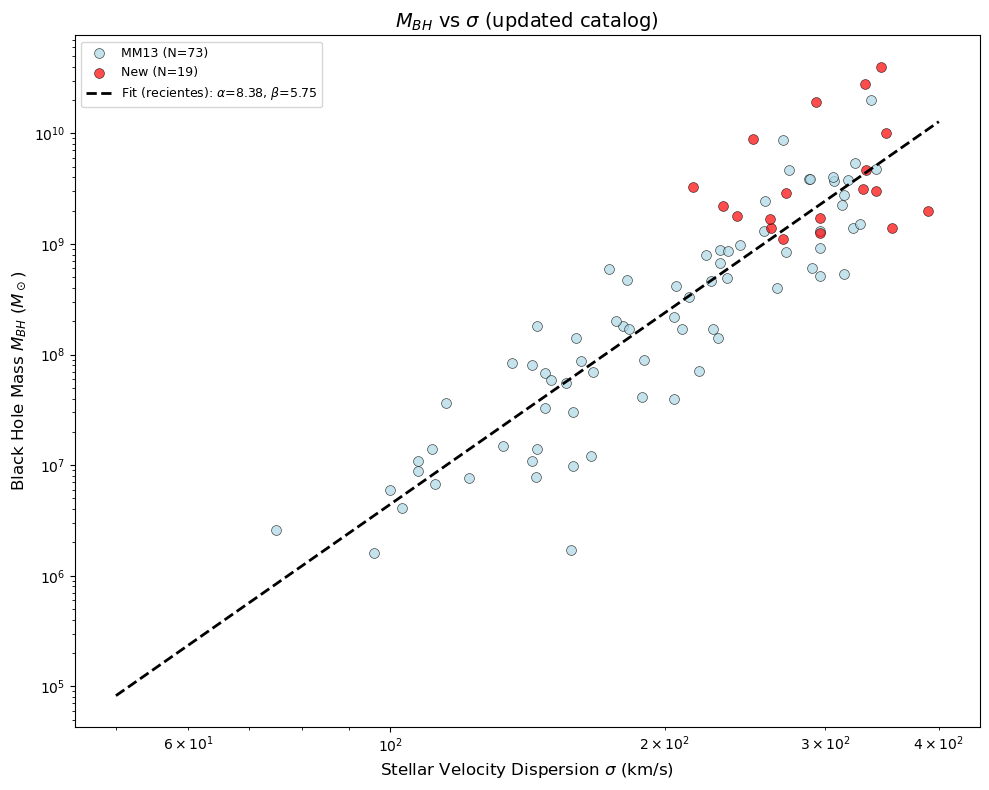

Fit con galaxias recientes (N=92):
  alpha = 8.376
  beta  = 5.747


In [13]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)", fontsize=12)
ax.set_ylabel("Black Hole Mass $M_{BH}$ ($M_\odot$)", fontsize=12)
ax.set_title("$M_{BH}$ vs $\sigma$ (updated catalog)", fontsize=14)

# Grupo 1: MM13 + MM13_updated (las que ya estaban en MM13, actualizadas o no)
mask_mm13 = df_table["Source"].isin(["MM13", "MM13_updated"])
sub_mm13 = df_table[mask_mm13]
ax.scatter(sub_mm13["sigma"], sub_mm13["M_BH"],
           color="lightblue", s=50, alpha=0.7,
           edgecolors="black", linewidths=0.5,
           label=f"MM13 (N={len(sub_mm13)})")

# Grupo 2: New
mask_new = df_table["Source"] == "New"
sub_new = df_table[mask_new]
ax.scatter(sub_new["sigma"], sub_new["M_BH"],
           color="red", s=50, alpha=0.7,
           edgecolors="black", linewidths=0.5,
           label=f"New (N={len(sub_new)})")
        

logx = np.log10(df_table["sigma"] / 200.0)
logy = np.log10(df_table["M_BH"])
beta, alpha = np.polyfit(logx, logy, 1)

# Dibujar línea del fit
sigma_grid = np.linspace(50, 400, 200)
x_grid = np.log10(sigma_grid / 200.0)
y_fit = alpha + beta * x_grid
ax.plot(sigma_grid, 10**y_fit, "k--", linewidth=2,
        label=f"Fit (recientes): $\\alpha$={alpha:.2f}, $\\beta$={beta:.2f}")

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("grafico1.jpg", dpi=300, bbox_inches="tight")
plt.show()

print(f"Fit con galaxias recientes (N={len(df_table)}):")
print(f"  alpha = {alpha:.3f}")
print(f"  beta  = {beta:.3f}")




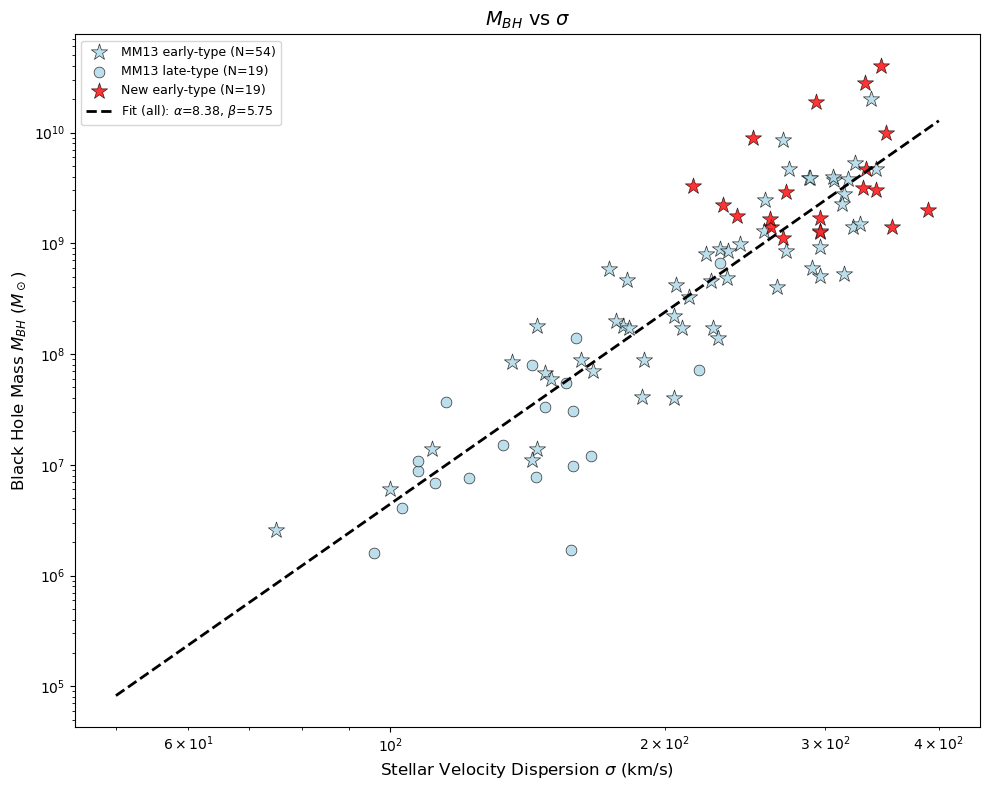

Fit con todas las galaxias (N=92):
  alpha = 8.376
  beta  = 5.747


In [16]:
# Definir early-type: E, S0, E/S0, S0/E (todo lo que no sea S puro)
# late-type: solo S


fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)", fontsize=12)
ax.set_ylabel("Black Hole Mass $M_{BH}$ ($M_\odot$)", fontsize=12)
ax.set_title("$M_{BH}$ vs $\sigma$", fontsize=14)


# (source_label, [sources], [morphs], color, marker)
early_types = ["E", "S0", "E/S0", "S0/E"]
combinaciones = [
    ("MM13 early-type",   ["MM13", "MM13_updated"],  early_types, "lightblue", "*"),
    ("MM13 late-type",    ["MM13", "MM13_updated"],   ["S"],        "lightblue", "o"),
    ("New early-type",    ["New"],                  early_types, "red",       "*"),
    ("New late-type",     ["New"],                   ["S"],        "red",       "o"),
]

for label, sources, morphs, color, marker in combinaciones:
    # Filtrar: Source en la lista Y Morph en la lista
    sub = df_table[df_table["Source"].isin(sources) & df_table["Morph"].isin(morphs)]
    if len(sub) > 0:
        # Las estrellitas las hacemos más grandes para que se vean bien
        size = 150 if marker == "*" else 60
        ax.scatter(sub["sigma"], sub["M_BH"],
                   color=color, marker=marker, s=size, alpha=0.8,
                   edgecolors="black", linewidths=0.5,
                   label=f"{label} (N={len(sub)})")

# Fit con todas las galaxias
logx = np.log10(df_table["sigma"] / 200.0)
logy = np.log10(df_table["M_BH"])
beta, alpha = np.polyfit(logx, logy, 1)

sigma_grid = np.linspace(50, 400, 200)
x_grid = np.log10(sigma_grid / 200.0)
y_fit = alpha + beta * x_grid
ax.plot(sigma_grid, 10**y_fit, "k--", linewidth=2,
        label=f"Fit (all): $\\alpha$={alpha:.2f}, $\\beta$={beta:.2f}")

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("grafico2.jpg")
plt.show()

print(f"Fit con todas las galaxias (N={len(df_table)}):")
print(f"  alpha = {alpha:.3f}")
print(f"  beta  = {beta:.3f}")


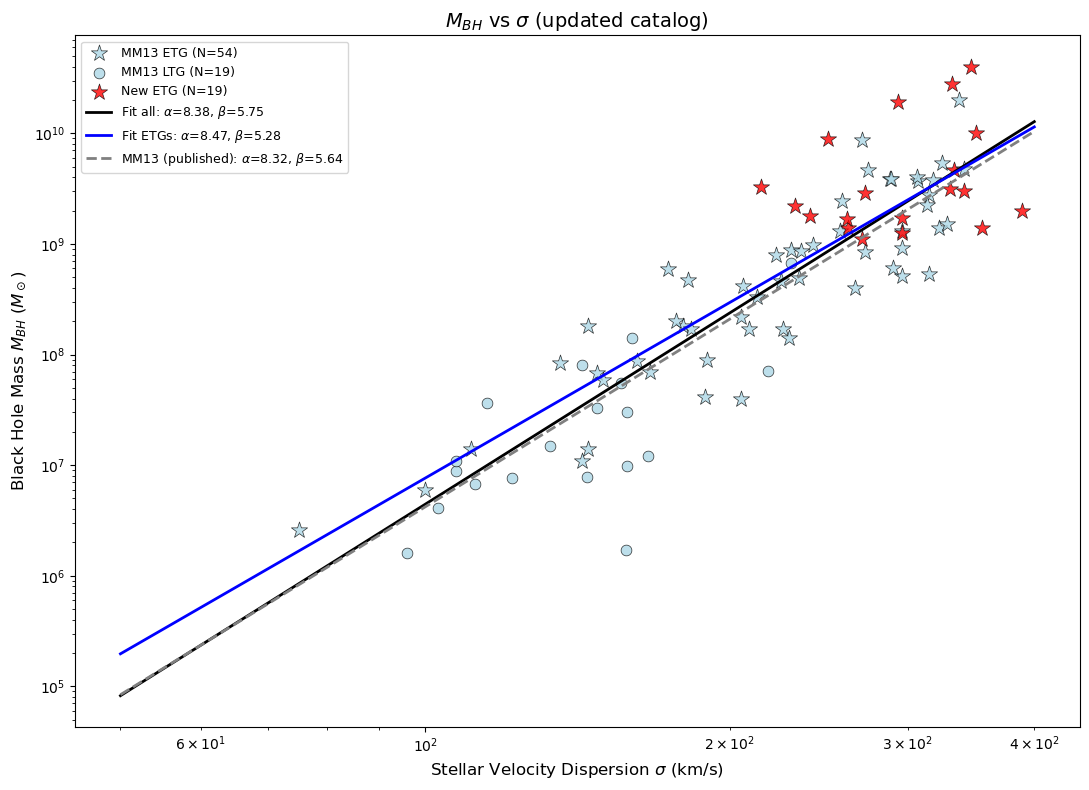

=== Resultados de los 3 fits ===
  All  (N=92):    α=8.376, β=5.747
  ETGs (N=73):     α=8.470, β=5.275
  MM13 (published):  α=8.320, β=5.640



In [17]:

early_types = ["E", "S0", "E/S0", "S0/E"]

fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Stellar Velocity Dispersion $\sigma$ (km/s)", fontsize=12)
ax.set_ylabel("Black Hole Mass $M_{BH}$ ($M_\odot$)", fontsize=12)
ax.set_title("$M_{BH}$ vs $\sigma$ (updated catalog)", fontsize=14)

combinaciones = [
    ("MM13 ETG",  ["MM13", "MM13_updated"], early_types, "lightblue", "*",    150),
    ("MM13 LTG",  ["MM13", "MM13_updated"], ["S"],        "lightblue", "o",     60),
    ("New ETG",   ["New"],                 early_types, "red",       "*",    150),
    ("New LTG",   ["New"],                 ["S"],        "red",       "o",     60),
]

for label, sources, morphs, color, marker, size in combinaciones:
    sub = df_table[df_table["Source"].isin(sources) & df_table["Morph"].isin(morphs)]
    if len(sub) > 0:
        ax.scatter(sub["sigma"], sub["M_BH"],
                   color=color, marker=marker, s=size, alpha=0.8,
                   edgecolors="black", linewidths=0.5,
                   label=f"{label} (N={len(sub)})")

#  Fit 1: TODAS las galaxias negro sólido
logx_all = np.log10(df_table["sigma"] / 200.0)
logy_all = np.log10(df_table["M_BH"])
beta_all, alpha_all = np.polyfit(logx_all, logy_all, 1)

sigma_grid = np.linspace(50, 400, 200)
x_grid = np.log10(sigma_grid / 200.0)
y_all = alpha_all + beta_all * x_grid
ax.plot(sigma_grid, 10**y_all, "k-", linewidth=2,
        label=f"Fit all: $\\alpha$={alpha_all:.2f}, $\\beta$={beta_all:.2f}")

# Fit 2: solo ETGs azul sólido
df_etg = df_table[df_table["Morph"].isin(early_types)]
logx_etg = np.log10(df_etg["sigma"] / 200.0)
logy_etg = np.log10(df_etg["M_BH"])
beta_etg, alpha_etg = np.polyfit(logx_etg, logy_etg, 1)

y_etg = alpha_etg + beta_etg * x_grid
ax.plot(sigma_grid, 10**y_etg, "b-", linewidth=2,
        label=f"Fit ETGs: $\\alpha$={alpha_etg:.2f}, $\\beta$={beta_etg:.2f}")

# Fit 3: McConnell & Ma 2013 publicado gris punteado
alpha_mm13 = 8.32
beta_mm13  = 5.64
y_mm13 = alpha_mm13 + beta_mm13 * x_grid
ax.plot(sigma_grid, 10**y_mm13, "--", color="gray", linewidth=2,
        label=f"MM13 (published): $\\alpha$=8.32, $\\beta$=5.64")

ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("grafico_final.png", dpi=300, bbox_inches="tight")  
plt.show()

# Mostrar resultados
print("=== Resultados de los 3 fits ===")
print(f"  All  (N={len(df_table)}):    α={alpha_all:.3f}, β={beta_all:.3f}")
print(f"  ETGs (N={len(df_etg)}):     α={alpha_etg:.3f}, β={beta_etg:.3f}")
print(f"  MM13 (published):  α=8.320, β=5.640")
print()